In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("C:/Users/HP/Downloads/archive (8)/car data.csv")

In [4]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [5]:
df.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
df.isnull().sum

<bound method DataFrame.sum of      Car_Name   Year  Selling_Price  Present_Price  Kms_Driven  Fuel_Type  \
0       False  False          False          False       False      False   
1       False  False          False          False       False      False   
2       False  False          False          False       False      False   
3       False  False          False          False       False      False   
4       False  False          False          False       False      False   
..        ...    ...            ...            ...         ...        ...   
296     False  False          False          False       False      False   
297     False  False          False          False       False      False   
298     False  False          False          False       False      False   
299     False  False          False          False       False      False   
300     False  False          False          False       False      False   

     Seller_Type  Transmission  Owner  
0   

In [10]:
import sklearn
import seaborn as sns

In [12]:
x = df.iloc[:,[0,1,3,4,5]]

In [13]:
x

,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type
0,ritz,2014,5.59,27000,Petrol
1,sx4,2013,9.54,43000,Diesel
2,ciaz,2017,9.85,6900,Petrol
3,wagon r,2011,4.15,5200,Petrol
4,swift,2014,6.87,42450,Diesel
...,...,...,...,...,...
296,city,2016,11.60,33988,Diesel
297,brio,2015,5.90,60000,Petrol
298,city,2009,11.00,87934,Petrol
299,city,2017,12.50,9000,Diesel


In [14]:
y = df.iloc[:,[2]]

In [15]:
y

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60
...,...
296,9.50
297,4.00
298,3.35
299,11.50


In [16]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [19]:
x_train

,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type
143,Yamaha FZ v 2.0,2016,0.840,25000,Petrol
64,fortuner,2017,36.230,6000,Diesel
194,Hero CBZ Xtreme,2008,0.787,50000,Petrol
208,i20,2017,8.100,3435,Petrol
18,wagon r,2015,5.090,35500,CNG
...,...,...,...,...,...
79,fortuner,2012,30.610,89000,Diesel
223,verna,2015,9.400,61381,Diesel
218,verna,2014,9.400,45078,Petrol
283,city,2016,11.800,9010,Petrol


In [20]:
y_train

,Selling_Price
143,0.60
64,33.00
194,0.20
208,7.90
18,3.25
...,...
79,14.50
223,8.25
218,6.45
283,8.99


In [21]:
x_test

,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type
201,i20,2010,6.790,58000,Diesel
165,Activa 3g,2016,0.540,500,Petrol
26,swift,2013,5.870,55138,Petrol
137,Hero Extreme,2013,0.787,16000,Petrol
234,grand i10,2015,5.700,4492,Petrol
0,ritz,2014,5.590,27000,Petrol
102,KTM RC200,2017,1.780,4000,Petrol
94,corolla altis,2008,22.780,89000,Petrol
296,city,2016,11.600,33988,Diesel
115,Royal Enfield Classic 350,2015,1.470,17500,Petrol


In [22]:
y_test

,Selling_Price
201,3.25
165,0.45
26,4.15
137,0.65
234,5.50
0,3.35
102,1.65
94,4.00
296,9.50
115,1.11


In [1]:
# using OHE because training data has string
# will use coulmntransformer for better scaling

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [66]:
# Column Transformer
transformer = ColumnTransformer(
    transformers=[
        
        # One Hot Encoding
        ('pr', OneHotEncoder(sparse=False,drop='first',handle_unknown='ignore'),
         ['Car_Name', 'Fuel_Type']),
        
        # Scaling
        ('raj', StandardScaler(),
         ['Year', 'Present_Price', 'Kms_Driven'])
    ]
)

# Transform data
transformer.fit_transform(x_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


array([[ 0.        ,  0.        ,  0.        , ...,  0.81723256,
        -0.77207174, -0.37761137],
       [ 0.        ,  0.        ,  0.        , ...,  1.15986112,
         3.18154258, -1.04407746],
       [ 0.        ,  0.        ,  0.        , ..., -1.92379591,
        -0.77799267,  0.4993177 ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.13197544,
         0.18421361,  0.3266679 ],
       [ 0.        ,  0.        ,  0.        , ...,  0.81723256,
         0.452331  , -0.93849521],
       [ 0.        ,  0.        ,  0.        , ..., -1.92379591,
        -0.80111779, -1.18789383]])

In [34]:
transformer.fit_transform(x_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


(270, 99)

In [44]:
transformer.fit_transform(x_test).shape

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


(31, 26)

In [47]:
x_train_processed = transformer.fit_transform(x_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [45]:
x_test_processed = transformer.transform(x_test)

In [39]:
from sklearn.linear_model import LinearRegression

In [49]:
model = LinearRegression()

model.fit(x_train_processed, y_train)

LinearRegression()

In [2]:
# importing pipeline because it lowers error

from sklearn.pipeline import Pipeline

In [52]:
# Pipeline
model = Pipeline(steps=[
    ('transformer', transformer),
    ('regressor', LinearRegression())
])

In [53]:
# Train
model.fit(x_train, y_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse=False),
                                                  ['Car_Name', 'Fuel_Type']),
                                                 ('num', StandardScaler(),
                                                  ['Year', 'Present_Price',
                                                   'Kms_Driven'])])),
                ('regressor', LinearRegression())])

In [54]:
# Predict
y_pred = model.predict(x_test)

print(y_pred)

[[ 2.78872141]
 [ 8.84037352]
 [ 2.61078361]
 [ 0.05032512]
 [ 5.22022294]
 [ 4.77455233]
 [ 1.72700241]
 [ 7.73727714]
 [ 9.10735124]
 [ 1.29847958]
 [-1.19436957]
 [11.02111291]
 [-8.60123134]
 [ 3.41001461]
 [ 1.18444897]
 [ 3.3535678 ]
 [ 4.50354116]
 [11.63524419]
 [ 6.88469642]
 [ 4.57234187]
 [ 9.30992503]
 [ 5.19139718]
 [ 2.99302437]
 [ 8.56386579]
 [13.55462786]
 [ 5.81963165]
 [ 4.3620722 ]
 [ 6.11133661]
 [ 5.73800697]
 [ 6.69811867]
 [ 0.89562264]]


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:228: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [55]:
from sklearn.metrics import r2_score

In [57]:
# Got Bad Score 

score = r2_score(y_test, y_pred)

print(score)

-0.015404524082977211


In [58]:
# Trying RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor

model = Pipeline(steps=[
    ('transformer', transformer),
    
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Score
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print(score)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9459094503375307


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:228: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [63]:
# Comparing Actual vs Predicted

comparison = pd.DataFrame({
    'Actual': y_test.values.ravel(),
    'Predicted': y_pred.ravel()
})

print(comparison.head())

   Actual  Predicted
0    3.25     2.4490
1    0.45     0.4337
2    4.15     3.8020
3    0.65     0.4493
4    5.50     5.1125


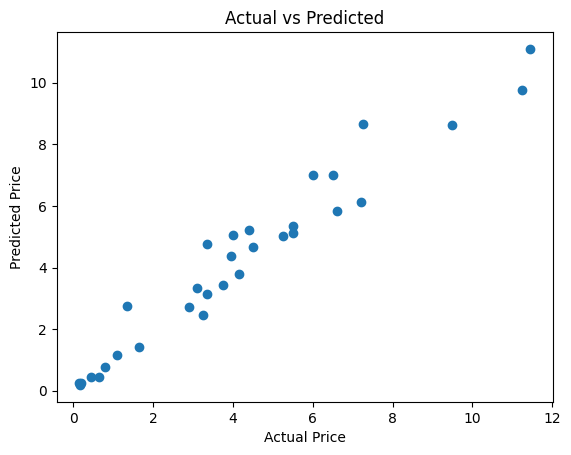

In [64]:
# Plotting

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [65]:
import joblib

joblib.dump(model, 'car_price_model.pkl')

['car_price_model.pkl']